In [655]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from IPython.display import display, HTML

In [656]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# np.set_printoptions(threshold=np.inf, linewidth=400, precision=2)

# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"

In [657]:
# 全局变量：保存上一帧数据，用于实时计算
prev_frame = None 

In [658]:
# ===================== 数组自动网格输出（你要的格式） =====================
def auto_print(data, title):
    print(f"\n{'='*60}")
    print(f"📌 {title} | 形状 = {data.shape}")
    vec = data[0]
    n = len(vec)
    
    if n == 84:
        rows, cols = 7, 12
    elif n == 77:
        rows, cols = 7, 11
    elif n == 72:
        rows, cols = 6, 12
    elif n == 66:
        rows, cols = 6, 11
    else:
        print(vec)
        return
    
    print(f"✅ 输出格式：{rows}行 × {cols}列")
    print("-" * (cols * 7))
    grid = vec.reshape(rows, cols)
    for i in range(rows):
        print(f"行{i+1:2d} | " + " ".join(f"{v:6.1f}" for v in grid[i]))

# 打印全部行的矩阵
def print_full_matrix(data, title, rows, cols):
    print(f"\n{'='*60}")
    print(f"📌 {title} | 全部行 | {rows}×{cols}")
    for i in range(data.shape[0]):
        print(f"\n--- 第 {i+1} 行 ---")
        grid = data[i].reshape(rows, cols)
        for r in range(rows):
            print(f"行{r+1:2d} | " + " ".join(f"{v:6.1f}" for v in grid[r]))

In [659]:
# 生成有效区间索引 [9,10,11,12,13,16,17,...,76] → 共50个
VALID_INDICES = []
start = 9
for i in range(10):
    base = start + i * 7
    VALID_INDICES.extend([base, base+1, base+2, base+3, base+4])

In [660]:
# ===================== 基线扣除 + 有效区间内局部极大值 =====================
global first_frame
first_frame = None

def subtract_baseline(current_frame):
    global first_frame
    current_frame = np.array(current_frame, dtype=np.float32).flatten()
    cols = 7

    if first_frame is None:
        first_frame = current_frame.copy()

    # 基线扣除
    diff_frame = current_frame - first_frame
    abs_diff = np.abs(diff_frame)

    peak_cols = []

    # 遍历所有通道
    for col_idx in range(len(abs_diff)):
        # ===================== 只判断：是否在有效区间 =====================
        is_valid = False
        start = 9
        for i in range(10):
            low = start + i * 7
            high = low + 4
            if low <= col_idx <= high:
                is_valid = True
                break
        
        # 不在有效区间直接跳过
        if not is_valid:
            continue

        # ===================== 局部极大值判断 =====================
        current_val = abs_diff[col_idx]
        left_val  = abs_diff[col_idx - 1]
        right_val = abs_diff[col_idx + 1]
        up_val    = abs_diff[col_idx - cols]
        down_val  = abs_diff[col_idx + cols]

        if (current_val > left_val and
            current_val > right_val and
            current_val > up_val and
            current_val > down_val):

            peak_cols.append(col_idx)

    return diff_frame, peak_cols

In [661]:
# ===================== 列差分（批量处理 + 输出固定50维） =====================
def compute_diff_adjacent(frame, peak_cols):
    frame = np.array(frame)
    output = np.zeros(50, dtype=np.float32)  # 保留 50 维
    
    # 批量处理所有峰值
    for col in peak_cols:
        diff = frame[col + 1] - frame[col - 1]
        idx = VALID_INDICES.index(col)  # 保留原来的索引映射
        output[idx] = diff  # 直接写入对应位置
    
    return output  # 返回 50 维向量

In [662]:
# ===================== 行差分（批量处理 + 输出固定50维） =====================
def compute_diff_7step(frame, peak_cols):
    frame = np.array(frame)
    output = np.zeros(50, dtype=np.float32)  # 保留 50 维
    
    # 批量处理所有峰值
    for col in peak_cols:
        diff = frame[col + 7] - frame[col - 7]
        idx = VALID_INDICES.index(col)  # 保留原来逻辑
        output[idx] = diff
    
    return output  # 返回 50 维向量

In [663]:
# -------------------- 4. 计算ADC角度 --------------------
def compute_gradient_angle(x_diff, y_diff):
    """
    输入：
      x_diff = compute_diff_adjacent 返回值（横向差分：右-左）
      y_diff = compute_diff_7step 返回值（纵向差分：上7-下7）
    输出：
      0~360° 角度
    """
    epsilon = 1e-8
    
    # 直接计算方向角
    angle = np.degrees(np.arctan2(-y_diff, -x_diff + epsilon))
    
    # 转为 0~360°
    if angle < 0:
        angle += 360
        
    return angle

In [664]:
# -------------------- 5. 计算Force角度 --------------------
def compute_force_angle(Fx, Fy):
    import numpy as np
    epsilon = 1e-8
    angle = np.degrees(np.arctan2(Fy, Fx + epsilon))
    angle = angle + 360 if angle < 0 else angle
    return angle

In [665]:
# -------------------- 4. 计算diff_adjacent_7step 先列再行二次差分 --------------------


In [666]:
# ================================== 主程序（已适配新版函数） ==================================
import pandas as pd
import numpy as np

# 1. 读取数据
df = pd.read_csv('/home/qcy/Project/data/2.PZT_tangential/weight/test/data_4.csv')
data_original = df.iloc[:, 2:86].values

force_Fx = df.iloc[:, 86].values
force_Fy = df.iloc[:, 87].values

# 2. 初始化存储数组
data_diff = np.zeros_like(data_original)          # 基线扣除结果 (N,84)
diff_adjacent_list = []                           # 列差分结果 (N,72)
diff_adjacent7_list = []                          # 行差分结果 (N,50)
ADC_angle_list = []                               # 角度结果 (N,66) 
force_angle_list = []                             # Force角度结果 (N,1)
peak_cols_list = []                               # 所有峰值列号列表

# 3. 主循环
for i in range(data_original.shape[0]):
    # -------------------- 步骤1：基线扣除 + 获取所有峰值列 --------------------
    current_frame = data_original[i]
    diff_frame, peak_cols = subtract_baseline(current_frame)
    data_diff[i] = diff_frame
    peak_cols_list.append(peak_cols)  # 保存所有峰值列

    # -------------------- 步骤2：列差分（直接传 peak_cols） --------------------
    adj_rows = compute_diff_adjacent(diff_frame, peak_cols)
    
    # -------------------- 步骤3：行差分（直接传 peak_cols） --------------------
    adj_cols = compute_diff_7step(diff_frame, peak_cols)

    # 这两行保留
    diff_adjacent_list.append(adj_rows)
    diff_adjacent7_list.append(adj_cols)

    # -------------------- 步骤4：计算ADC角度 --------------------
    angles = []
    for xr, yr in zip(adj_rows, adj_cols):
        ang = compute_gradient_angle(xr, yr)
        angles.append(ang)
    
    ADC_angle_list.append(angles)

    # -------------------- 步骤5：计算Force角度 --------------------   
    fx = force_Fx[i]
    fy = force_Fy[i]
    f_angle = compute_force_angle(fx, fy)
    force_angle_list.append(f_angle)

# 转成numpy数组
diff_adjacent = np.array(diff_adjacent_list, dtype=object)
diff_adjacent7 = np.array(diff_adjacent7_list, dtype=object)
gradient_angle = np.array(ADC_angle_list, dtype=object)
force_angle = np.array(force_angle_list)
peak_cols_array = np.array(peak_cols_list, dtype=object)

In [667]:
# ===================== 打印输出 =====================
print(f"\n✅ data_original shape: {data_original.shape}")
print_full_matrix(data_original, "data_original", 12, 7)


✅ data_original shape: (258, 84)

📌 data_original | 全部行 | 12×7

--- 第 1 行 ---
行 1 |  415.0  167.0  106.0  129.0    7.0  133.0   55.0
行 2 |  179.0  106.0   65.0   68.0    7.0   44.0   19.0
行 3 |  129.0   92.0   62.0   63.0    7.0   47.0   25.0
行 4 |   67.0   57.0   40.0   43.0    7.0   33.0   22.0
行 5 |   75.0   89.0   60.0   87.0    7.0   89.0   61.0
行 6 |   61.0   86.0   60.0  101.0    7.0  125.0   75.0
行 7 |   25.0   37.0   27.0   30.0    9.0   33.0   33.0
行 8 |   36.0   80.0   35.0   49.0    7.0   66.0  103.0
行 9 |   28.0   54.0   24.0   24.0    7.0   33.0   39.0
行10 |   14.0   11.0   13.0   10.0    7.0    8.0    8.0
行11 |   25.0   83.0   27.0   27.0   12.0   52.0  148.0
行12 |   33.0  247.0   32.0   41.0    7.0  130.0  430.0

--- 第 2 行 ---
行 1 |  415.0  167.0  103.0  129.0    7.0  130.0   50.0
行 2 |  179.0  100.0   62.0   65.0    7.0   44.0   19.0
行 3 |  129.0   95.0   60.0   63.0    7.0   44.0   25.0
行 4 |   64.0   57.0   41.0   43.0    7.0   33.0   22.0
行 5 |   75.0   89.0   60.0

In [668]:
print(f"\n✅ data_diff 基线扣除 shape: {data_diff.shape}")
print_full_matrix(data_diff, "data_diff 基线扣除", 12, 7)


✅ data_diff 基线扣除 shape: (258, 84)

📌 data_diff 基线扣除 | 全部行 | 12×7

--- 第 1 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 3 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 4 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 5 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 6 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 7 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 8 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 9 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行10 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行11 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行12 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0

--- 第 2 行 ---
行 1 |    0.0    0.0   -3.0    0.0    0.0   -3.0   -5.0
行 2 |    0.0   -6.0   -3.0   -3.0    0.0    0.0    0.0
行 3 |    0.0    3.0   -2.0    0.0    0.0   -3.0    0.0
行 4 |   -3.0    0.0    1.0    0.0    0.0    0.0    0.0
行 5 |    0.0    0.0    0

In [669]:
print(f"✅ diff_adjacent 列差分 shape: {diff_adjacent.shape}")
print_full_matrix(diff_adjacent, "diff_adjacent 列差分", 10, 5)

✅ diff_adjacent 列差分 shape: (258, 50)

📌 diff_adjacent 列差分 | 全部行 | 10×5

--- 第 1 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0    0.0    0.0    0.0
行 3 |    0.0    0.0    0.0    0.0    0.0
行 4 |    0.0    0.0    0.0    0.0    0.0
行 5 |    0.0    0.0    0.0    0.0    0.0
行 6 |    0.0    0.0    0.0    0.0    0.0
行 7 |    0.0    0.0    0.0    0.0    0.0
行 8 |    0.0    0.0    0.0    0.0    0.0
行 9 |    0.0    0.0    0.0    0.0    0.0
行10 |    0.0    0.0    0.0    0.0    0.0

--- 第 2 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0    0.0    0.0    0.0
行 3 |    0.0    0.0    0.0    0.0    0.0
行 4 |    0.0    0.0    0.0    0.0    0.0
行 5 |    0.0    0.0    0.0    0.0    0.0
行 6 |    0.0    0.0    0.0    0.0    0.0
行 7 |   -3.0    0.0    0.0    0.0    0.0
行 8 |    0.0    0.0    0.0    0.0    0.0
行 9 |    0.0    0.0    0.0    0.0    0.0
行10 |    0.0    0.0    0.0    0.0    0.0

--- 第 3 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0    

In [670]:
print(f"✅ diff_adjacent7 行差分 shape: {diff_adjacent7.shape}")
print_full_matrix(diff_adjacent7, "diff_adjacent7 行差分", 10, 5)

✅ diff_adjacent7 行差分 shape: (258, 50)

📌 diff_adjacent7 行差分 | 全部行 | 10×5

--- 第 1 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0    0.0    0.0    0.0
行 3 |    0.0    0.0    0.0    0.0    0.0
行 4 |    0.0    0.0    0.0    0.0    0.0
行 5 |    0.0    0.0    0.0    0.0    0.0
行 6 |    0.0    0.0    0.0    0.0    0.0
行 7 |    0.0    0.0    0.0    0.0    0.0
行 8 |    0.0    0.0    0.0    0.0    0.0
行 9 |    0.0    0.0    0.0    0.0    0.0
行10 |    0.0    0.0    0.0    0.0    0.0

--- 第 2 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0    0.0    0.0    0.0
行 3 |    0.0    0.0    0.0    0.0    0.0
行 4 |    0.0    0.0    0.0    0.0    0.0
行 5 |    0.0    0.0    0.0    0.0    0.0
行 6 |    0.0    0.0    0.0    0.0    0.0
行 7 |    0.0    0.0    0.0    0.0    0.0
行 8 |    0.0    0.0    0.0    0.0    0.0
行 9 |    0.0    0.0    0.0    0.0    0.0
行10 |    0.0    0.0    0.0    0.0    0.0

--- 第 3 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0  

In [671]:
print(f"✅ gradient_angle ADC角度 shape: {gradient_angle.shape}")
print_full_matrix(gradient_angle, "gradient_angle ADC角度", 10, 5)

✅ gradient_angle ADC角度 shape: (258, 50)

📌 gradient_angle ADC角度 | 全部行 | 10×5

--- 第 1 行 ---
行 1 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 2 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 3 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 4 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 5 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 6 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 7 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 8 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 9 |   -0.0   -0.0   -0.0   -0.0   -0.0
行10 |   -0.0   -0.0   -0.0   -0.0   -0.0

--- 第 2 行 ---
行 1 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 2 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 3 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 4 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 5 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 6 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 7 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 8 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 9 |   -0.0   -0.0   -0.0   -0.0   -0.0
行10 |   -0.0   -0.0   -0.0   -0.0   -0.0

--- 第 3 行 ---
行 1 |   -0.0   -0.0   -0.0   -0.0   -0.0
行 2 |   -0.0   -0

In [672]:
print(f"✅ force_angle Force角度 shape: {force_angle.shape}")
print_full_matrix(force_angle, "force_angle Force角度", 1, 1)

✅ force_angle Force角度 shape: (258,)

📌 force_angle Force角度 | 全部行 | 1×1

--- 第 1 行 ---
行 1 |   -0.0

--- 第 2 行 ---
行 1 |   90.0

--- 第 3 行 ---
行 1 |  166.0

--- 第 4 行 ---
行 1 |  135.0

--- 第 5 行 ---
行 1 |  135.0

--- 第 6 行 ---
行 1 |  116.6

--- 第 7 行 ---
行 1 |  180.0

--- 第 8 行 ---
行 1 |  135.0

--- 第 9 行 ---
行 1 |  180.0

--- 第 10 行 ---
行 1 |  180.0

--- 第 11 行 ---
行 1 |  180.0

--- 第 12 行 ---
行 1 |  153.4

--- 第 13 行 ---
行 1 |  135.0

--- 第 14 行 ---
行 1 |  135.0

--- 第 15 行 ---
行 1 |  135.0

--- 第 16 行 ---
行 1 |  123.7

--- 第 17 行 ---
行 1 |  123.7

--- 第 18 行 ---
行 1 |  116.6

--- 第 19 行 ---
行 1 |  116.6

--- 第 20 行 ---
行 1 |  126.9

--- 第 21 行 ---
行 1 |  135.0

--- 第 22 行 ---
行 1 |  123.7

--- 第 23 行 ---
行 1 |  126.9

--- 第 24 行 ---
行 1 |  135.0

--- 第 25 行 ---
行 1 |  135.0

--- 第 26 行 ---
行 1 |  128.7

--- 第 27 行 ---
行 1 |  111.8

--- 第 28 行 ---
行 1 |  128.7

--- 第 29 行 ---
行 1 |  119.7

--- 第 30 行 ---
行 1 |  150.3

--- 第 31 行 ---
行 1 |  122.7

--- 第 32 行 ---
行 1 |  116.6

--- 第 33 

In [673]:
# ===================== 4. 拼接+保存 =====================
# 【修复】force_angle 确保变成 2 维 (N,1)
force_angle = np.array(force_angle_list).reshape(-1, 1)

# 【修复】angle 也变成标准 2 维 (N,50)
gradient_angle_2d = np.vstack([np.array(x).reshape(1, -1) for x in gradient_angle])

# 现在两个都是 2 维，可以完美拼接！
ADC_force_angle = np.hstack([gradient_angle_2d, force_angle])

print(f"✅ force_angle ADC+Force shape: {ADC_force_angle.shape}")

# 1. 构造列名：50 个ADC通道 + 1 个力角度
columns = [f"ADC_angle_{i+1}" for i in range(50)] + ["Force_angle"]

# 2. 转成标准二维表格
df_result = pd.DataFrame(ADC_force_angle, columns=columns)

# 3. 控制台输出
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 9999)
print("✅ 带列名的完整二维表格：")
print(df_result)

# 4. 保存
save_path = "/home/qcy/Project/data/2.PZT_tangential/weight/pre/ADC_Force_angle_result.csv"
df_result.to_csv(save_path, index=False, float_format="%.2f")

print(f"\n✅ 文件已保存到：\n{save_path}")

✅ force_angle ADC+Force shape: (258, 51)
✅ 带列名的完整二维表格：
    ADC_angle_1 ADC_angle_2 ADC_angle_3 ADC_angle_4 ADC_angle_5 ADC_angle_6 ADC_angle_7 ADC_angle_8 ADC_angle_9 ADC_angle_10 ADC_angle_11 ADC_angle_12 ADC_angle_13 ADC_angle_14 ADC_angle_15 ADC_angle_16 ADC_angle_17 ADC_angle_18 ADC_angle_19 ADC_angle_20 ADC_angle_21 ADC_angle_22 ADC_angle_23 ADC_angle_24 ADC_angle_25 ADC_angle_26 ADC_angle_27 ADC_angle_28 ADC_angle_29 ADC_angle_30 ADC_angle_31 ADC_angle_32 ADC_angle_33 ADC_angle_34 ADC_angle_35 ADC_angle_36 ADC_angle_37 ADC_angle_38 ADC_angle_39 ADC_angle_40 ADC_angle_41 ADC_angle_42 ADC_angle_43 ADC_angle_44 ADC_angle_45 ADC_angle_46 ADC_angle_47 ADC_angle_48 ADC_angle_49 ADC_angle_50 Force_angle
0          -0.0        -0.0        -0.0        -0.0        -0.0        -0.0        -0.0        -0.0        -0.0         -0.0         -0.0         -0.0         -0.0         -0.0         -0.0         -0.0         -0.0         -0.0         -0.0         -0.0         -0.0         -0.0        

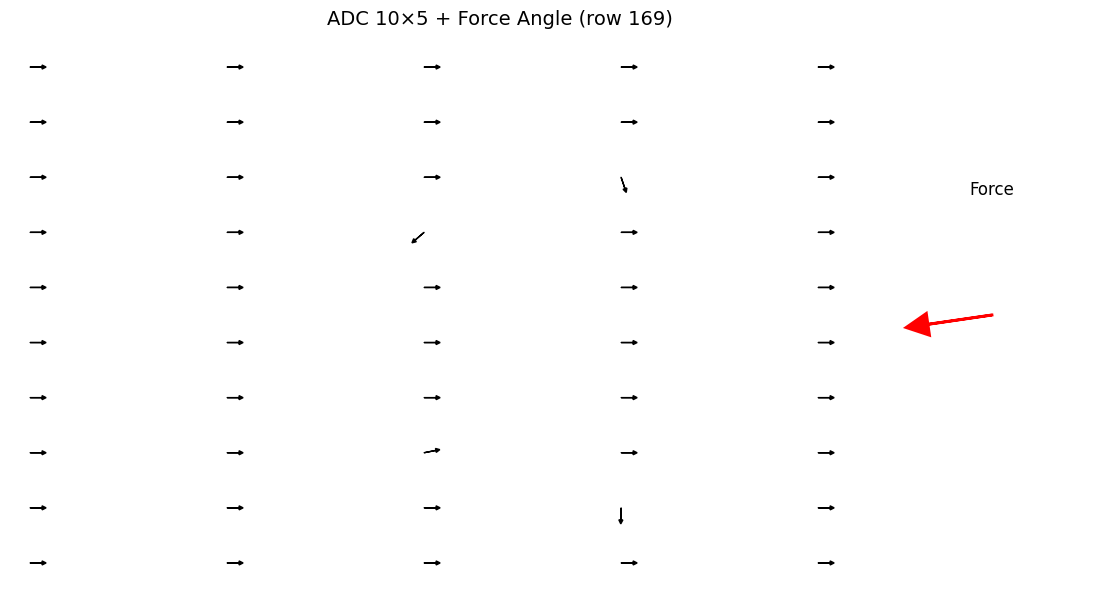

In [674]:
# ===================== 10×5 ADC + Force 同一行 · 左大右小 =====================
import matplotlib.pyplot as plt
import numpy as np

# 关闭多余输出
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "none"

row_idx = 168

# 数据
adc_angles = ADC_force_angle[row_idx, :50]
force_angle = ADC_force_angle[row_idx, -1]

# ===================== 正确布局：先创建 10x5 + 1 个图 =====================
# 总布局：10行，6列（前5列给ADC，最后1列给Force）
fig, axes = plt.subplots(10, 6, figsize=(12, 6), gridspec_kw={'width_ratios': [1,1,1,1,1, 0.8]})

# -------------------------- 左边 10×5：画 ADC 箭头 --------------------------
for idx in range(50):
    r = idx // 5
    c = idx % 5
    ax = axes[r, c]

    theta = np.deg2rad(adc_angles[idx])
    ax.arrow(0.5, 0.5,
             0.3 * np.cos(theta),
             0.3 * np.sin(theta),
             head_width=0.1, head_length=0.1,
             fc='k', ec='k', linewidth=1)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')

# -------------------------- 最右侧：画 Force 箭头（跨10行） --------------------------
# 把右边1列合并成一个大子图
from matplotlib.gridspec import GridSpec
gs = GridSpec(10, 6, figure=fig, width_ratios=[1,1,1,1,1,0.8])
ax_force = fig.add_subplot(gs[:, 5])

theta_f = np.deg2rad(force_angle)
ax_force.arrow(0.5, 0.5,
          0.35 * np.cos(theta_f),
          0.35 * np.sin(theta_f),
          head_width=0.12, head_length=0.12,
          fc='r', ec='r', linewidth=2)

ax_force.set_xlim(0, 1)
ax_force.set_ylim(0, 1)
ax_force.set_aspect('equal')
ax_force.axis('off')
ax_force.set_title(f"Force", fontsize=12, pad=20)

# 隐藏多余的子图
for r in range(10):
    axes[r,5].remove()

# 标题
fig.suptitle(f"ADC 10×5 + Force Angle (row {row_idx+1})", fontsize=14)
plt.tight_layout()
plt.show()